# Soil Evaporation Simulation

This notebook runs the **soil evaporation capacitance (SEC) model** ([Or & Lehman, 2019](https://doi.org/10.1029/2018WR024050)) on post-infiltration moisture from tropical cyclones over the Arabian Peninsula.

**Paper:** [Saleh et al., 2025](https://doi.org/10.1038/s43247-025-02493-w) - *Intensifying tropical cyclones in the Arabian Sea replenish depleting aquifers*

**Workflow (5 steps):**
1. Load soil parameters and infiltration shapefiles
2. Review which SEC parameter row applies to each soil type
3. Run evaporation simulations (one series per year × soil type)
4. Combine soil types into yearly tables with a **Total** column
5. Plot and save the figure

Run from the **repository root** (see README). Most logic lives in `src/sec_evaporation.py`; this notebook explains each step.


## Setup


In [13]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

from src.sec_evaporation import (
    DEFAULT_YEARS,
    KM3_DISPLAY_DECIMALS,
    SOIL_TYPE_PARAM_MAP,
    load_infiltration_gdfs,
    load_soil_params,
    plot_soil_evaporation,
    prepare_evaporation_data,
    repo_root,
    run_all_simulations,
    summarize_simulation_runs,
    summarize_yearly_totals,
)

BASE_DIR = repo_root(ROOT)
FIGURE_PATH = BASE_DIR / "outputs" / "figures" / "soil_evaporation_by_year.jpeg"
years = DEFAULT_YEARS  # TC years: 2011, 2018, 2020


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1 - Load inputs

- **`soil_params`**: hydraulic properties for each SEC parameter set (`theta_sat`, `theta_crit`, `ks`, `et`, etc.)
- **`gdfs`**: infiltration shapefiles per year and soil type; each polygon has **`s_mm`** (initial moisture, mm) and **`area_m2`** (polygon area)


In [14]:
soil_params = load_soil_params(BASE_DIR)
gdfs = load_infiltration_gdfs(years, BASE_DIR)
soil_params


,site,theta_res,theta_sat,alpha,n,ks,m,h_crit,theta_crit,theta_mean,et,k_eff_m,lc,es
0,USDk1,0.0400,0.400,1.10,1.5000,0.2900,0.330000,3.910000,0.220000,0.301388,14.3,0.000929,0.230000,12.410616
1,USMo1,0.0416,0.386,3.15,1.4061,0.4092,0.288813,1.573452,0.216261,0.301131,14.3,0.000947,0.096412,12.383279
2,USMo7,0.0411,0.385,4.03,1.6809,0.9430,0.405081,0.883346,0.179427,0.282063,14.3,0.004695,0.210000,12.808199


In [15]:
# Count infiltration polygons loaded per soil type (sanity check on shapefile coverage).
for year in years:
    n_polygons = {soil: len(gdf) for soil, gdf in gdfs[year].items()}
    print(f"{year}: {n_polygons}")


2011: {'dunes': 80, 'alluvium': 148, 'hard_limestone': 153, 'karstified_limestone': 134}
2018: {'dunes': 114, 'alluvium': 119, 'hard_limestone': 122, 'karstified_limestone': 105}
2020: {'dunes': 54, 'alluvium': 154, 'hard_limestone': 157, 'karstified_limestone': 144}


## Step 2 - Soil-type → parameter mapping

Each infiltration soil class uses one row from `soil_param.xlsx` (column `site`).


In [16]:
pd.DataFrame(
    [{"soil_type": soil, "param_site": site} for soil, site in SOIL_TYPE_PARAM_MAP.items()]
)


,soil_type,param_site
0,dunes,USMo1
1,karstified_limestone,USMo1
2,alluvium,USMo7
3,hard_limestone,USDk1


## Step 3 - Run SEC simulations

`run_all_simulations` returns cumulative evaporation (km³) time series for each year and soil type.


In [17]:
processed_soil_evap_vol = run_all_simulations(gdfs, soil_params, years)
simulation_summary = summarize_simulation_runs(processed_soil_evap_vol)
simulation_summary


Processing USMo1:   0%|          | 0/80 [00:00<?, ?it/s]

Processing USMo7:   0%|          | 0/148 [00:00<?, ?it/s]

Processing USDk1:   0%|          | 0/153 [00:00<?, ?it/s]

Processing USMo1:   0%|          | 0/134 [00:00<?, ?it/s]

Processing USMo1:   0%|          | 0/114 [00:00<?, ?it/s]

...

Processing USMo1:   0%|          | 0/54 [00:00<?, ?it/s]

Processing USMo7:   0%|          | 0/154 [00:00<?, ?it/s]

Processing USDk1:   0%|          | 0/157 [00:00<?, ?it/s]

Processing USMo1:   0%|          | 0/144 [00:00<?, ?it/s]

,year,soil_type,param_site,n_days,final_evaporation_km3
0,2011,alluvium,USMo7,296,0.60
1,2011,dunes,USMo1,89,0.97
2,2011,hard_limestone,USDk1,471,1.30
3,2011,karstified_limestone,USMo1,89,0.14
4,2018,alluvium,USMo7,296,0.86
5,2018,dunes,USMo1,89,1.95
6,2018,hard_limestone,USDk1,471,1.93
7,2018,karstified_limestone,USMo1,89,0.18
8,2020,alluvium,USMo7,296,0.63
9,2020,dunes,USMo1,89,0.27


## Step 4 - Aggregate by TC year

`prepare_evaporation_data` merges simulations into yearly tables for 2011, 2018, and 2020.

Each table has columns for the four soil types plus **`Total`**.


In [18]:
processed_data = prepare_evaporation_data(processed_soil_evap_vol)
yearly_summary = summarize_yearly_totals(processed_data)
yearly_summary


,year,n_days,final_total_km3
0,2011,471,3.01
1,2018,471,4.92
2,2020,471,2.20


In [25]:
# Example: first rows of the 2018 table (TC Mekunu year)
processed_data[2018].head().round(KM3_DISPLAY_DECIMALS)


,dunes,alluvium,hard_limestone,karstified_limestone,Total
0,0.80,0.17,0.08,0.08,1.14
1,1.04,0.32,0.13,0.10,1.59
2,1.10,0.42,0.18,0.10,1.80
3,1.14,0.47,0.21,0.11,1.93
4,1.18,0.49,0.24,0.11,2.02


## Step 5 - Plot accumulated evaporation

Three panels (a-c) show 2011, 2018, and 2020. The dashed **Total** line is the sum of all soil types.


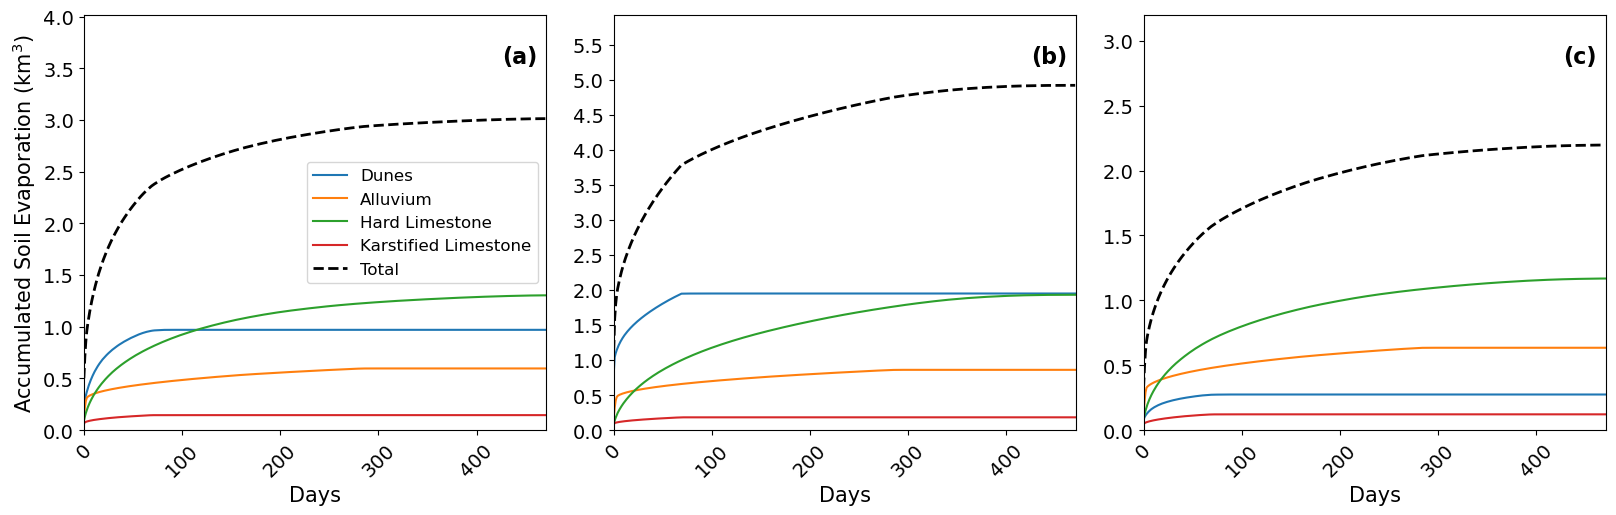

In [23]:
fig = plot_soil_evaporation(processed_data, save_path=FIGURE_PATH, 
                            show=True, figure_size=(16, 5))